# Проект: Статистический анализ данных

Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:

- без подписки
    - абонентская плата отсутствует;
    - стоимость одной минуты поездки — 8 рублей;
    - стоимость старта (начала поездки) — 50 рублей;
- с подпиской Ultra
    - абонентская плата — 199 рублей в месяц;
    - стоимость одной минуты поездки — 6 рублей;
    - стоимость старта — бесплатно.

### Описание данных

**Пользователи — users_go.csv**

- user_id — уникальный идентификатор пользователя
- name — имя пользователя
- age — возраст
- city — город
- subscription_type — тип подписки (free, ultra)

**Поeздки — rides_go.csv**

- user_id — уникальный идентификатор пользователя
- distance — расстояние, которое пользователь проехал в текущей сессии (в метрах)
- duration — продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал - - - - кнопку «Завершить поездку»
- date — дата совершения поездки

**Подписки — subscriptions_go.csv**

- subscription_type — тип подписки
- minute_price — стоимость одной минуты поездки по данной подписке
- start_ride_price — стоимость начала поездки
- subscription_fee — стоимость ежемесячного платежа

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import factorial
import numpy as np
from scipy import stats as st
from scipy.stats import binom
pd.set_option('display.float_format', '{:,.2f}'.format)
import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = 20

 ## Шаг 1. Загрузка и предобработка

### 1й датасет

In [ ]:
try:
    data_users= pd.read_csv('../data/users_go.csv')
except:
    data_users= pd.read_csv('../data/users_go.csv')

In [ ]:
data_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [ ]:
data_users.head()

   user_id        name  age            city subscription_type
0        1        Кира   22          Тюмень             ultra
1        2   Станислав   31            Омск             ultra
2        3     Алексей   20          Москва             ultra
3        4  Константин   26  Ростов-на-Дону             ultra
4        5       Адель   28            Омск             ultra

In [ ]:
# ищем дубликаты строк
duplicate_rows = data_users.duplicated()
# подсчитываем количество дубликатов
number_of_duplicates = duplicate_rows.sum()
# выводим количество дубликатов
print(f"Количество дубликатов строк: {number_of_duplicates}")
# выводим строки которые дублируются
print(f"Дублирующиеся строки:\n{data_users[duplicate_rows]}")

Количество дубликатов строк: 31
Дублирующиеся строки:
      user_id        name  age            city subscription_type
1534      293       Агата   26       Краснодар             ultra
1535       16      Амалия   27       Краснодар             ultra
1536      909  Константин   20    Екатеринбург              free
1537      403      Полина   19            Сочи             ultra
1538      908      Рустам   30          Тюмень              free
1539       43    Стефания   22            Омск             ultra
1540      127       Павел   25       Пятигорск             ultra
1541      659       Злата   27  Ростов-на-Дону             ultra
1542      204      Руслан   30       Пятигорск             ultra
1543      153      Герман   23          Москва             ultra
1544     1245      Регина   27       Пятигорск              free
1545      807   Александр   28    Екатеринбург              free
1546      924       Мария   23       Пятигорск              free
1547      635      Герман   21      

In [ ]:
# 31 дублирующая строка, удалим их 
data_users.drop_duplicates(inplace=True)
# выводим количество дубликатов после удаления
data_users.duplicated().sum()

0

In [ ]:
# смотрим пропуски строк
data_users.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

<div style="border:solid lightblue 4px; padding: 20px">

Вывод:

1) Мы загрузили дата сет и провели предобработку
2) Типы данных в столбцах соотвествуют значениям
3) Были удалены дублирующие строки
4) Датафрейм проверен на пропуски, пропуски отсутствуют

### 2-ой датасет data_rides

In [ ]:
try:
    data_rides= pd.read_csv('../data/rides_go.csv')
except:
    data_rides= pd.read_csv('../data/rides_go.csv')

In [ ]:
data_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [ ]:
# Приведем столбец к типу datetime и создадим столбец с месяцами
data_rides['date'] = pd.to_datetime(data_rides['date'])
data_rides['month'] = data_rides['date'].dt.month

In [ ]:
min_date = data_rides['date'].min()
max_date = data_rides['date'].max()

print(f"Минимальная дата в датасете: {min_date.strftime('%Y-%m-%d')}")
print(f"Максимальная дата в датасете: {max_date.strftime('%Y-%m-%d')}")

date_range = max_date - min_date
print(f"Период данных в датасете: {date_range}")

Минимальная дата в датасете: 2021-01-01
Максимальная дата в датасете: 2021-12-30
Период данных в датасете: 363 days 00:00:00


In [ ]:
# ищем дубликаты строк
rides_duplicate_rows = data_rides.duplicated()
# подсчитываем количество дубликатов
number_of_duplicates_rides = rides_duplicate_rows .sum()
# выводим количество дубликатов
print(f"Количество дубликатов строк: {number_of_duplicates_rides}")
# выводим строки которые дублируются
print(f"Дублирующиеся строки:\n{data_rides[rides_duplicate_rows]}")

Количество дубликатов строк: 0
Дублирующиеся строки:
Empty DataFrame
Columns: [user_id, distance, duration, date, month]
Index: []


In [ ]:
# смотрим пропуски строк
data_rides.isna().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [ ]:
data_rides.head()

   user_id  distance  duration       date  month
0        1  4,409.92     25.60 2021-01-01      1
1        1  2,617.59     15.82 2021-01-18      1
2        1    754.16      6.23 2021-04-20      4
3        1  2,694.78     18.51 2021-08-11      8
4        1  4,028.69     26.27 2021-08-28      8

<div style="border:solid lightblue 4px; padding: 20px">
Вывод:

1) Загрузили 2ой дата сет и провели предобработку
2) Типы данных в столбцах не соотвествуют значениям внутри, изменили столбец с датой на тип datetime
3) Дублирубщие строки и пустые значения отсутствуют
4) Данные в датасете с 2021-01-01 по 2021-12-30

### 3-й датасет subscriptions_go

In [ ]:
try:
    data_subscriptions= pd.read_csv('../data/subscriptions_go.csv')
except:
    data_subscriptions= pd.read_csv('../data/subscriptions_go.csv')

In [ ]:
data_subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


In [ ]:
data_subscriptions.head()

  subscription_type  minute_price  start_ride_price  subscription_fee
0              free             8                50                 0
1             ultra             6                 0               199

<div style="border:solid lightblue 4px; padding: 20px">

    Вывод:

1) В 3ем дата сете отсутствуют пропустки, типы данных корректны.

## Шаг 2. Исследовательский анализ данных

### Частота встречаемости городов

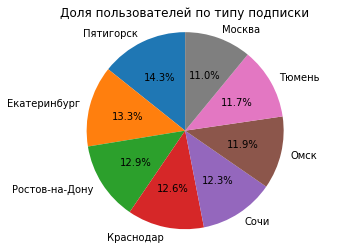

In [ ]:
subscription_counts = data_users['city'].value_counts()
plt.pie(subscription_counts.values, labels=subscription_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Доля пользователей по типу подписки')
plt.axis('equal')  
plt.show()

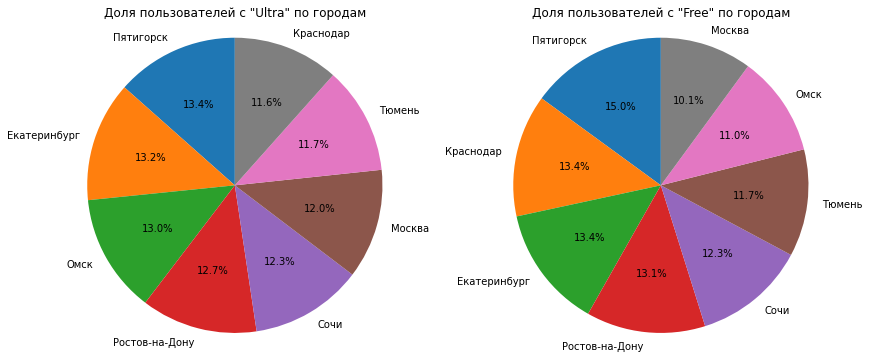

In [ ]:
# Фильтруем данные для пользователей с подпиской "Ultra"
data_ultra = data_users[data_users['subscription_type'] == 'ultra']
ultra_city_counts = data_ultra['city'].value_counts()

# Фильтруем данные для пользователей с подпиской "Free"
data_free = data_users[data_users['subscription_type'] == 'free']
free_city_counts = data_free['city'].value_counts()


fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # 1 строка, 2 столбца, размер графика

# Создаем первый график 
axes[0].pie(ultra_city_counts.values, labels=ultra_city_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Доля пользователей с "Ultra" по городам')
axes[0].axis('equal')

# Создаем второй график
axes[1].pie(free_city_counts.values, labels=free_city_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Доля пользователей с "Free" по городам')
axes[1].axis('equal')

plt.show()

In [ ]:
data_users['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

### Cоотношение пользователей с подпиской и без подписки;

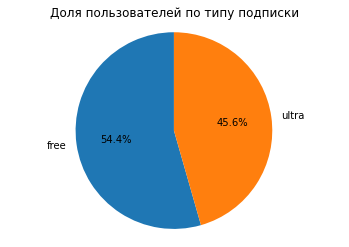

In [ ]:
subscription_counts = data_users['subscription_type'].value_counts()
plt.pie(subscription_counts.values, labels=subscription_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Доля пользователей по типу подписки')
plt.axis('equal')  
plt.show()

### Возраст пользователей

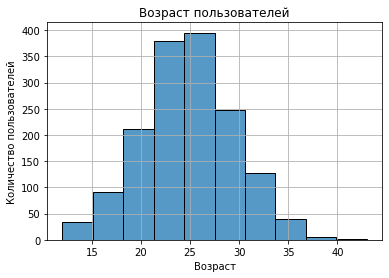

In [ ]:
sns.histplot(data=data_users, x='age', bins=10)
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

In [ ]:
data_users['age'].describe()

count   1,534.00
mean       24.90
std         4.57
min        12.00
25%        22.00
50%        25.00
75%        28.00
max        43.00
Name: age, dtype: float64

### Расстояние, которое пользователь преодолел за одну поездку;

In [ ]:
data_rides['distance'].sort_values(ascending=False)

16309   7,211.01
16484   7,066.00
15580   6,908.49
17171   6,760.94
17242   6,724.93
          ...   
7841        7.10
8658        6.78
13690       4.33
9541        2.57
11555       0.86
Name: distance, Length: 18068, dtype: float64

In [ ]:
data_rides['distance'].describe()

count   18,068.00
mean     3,070.66
std      1,116.83
min          0.86
25%      2,543.23
50%      3,133.61
75%      3,776.22
max      7,211.01
Name: distance, dtype: float64

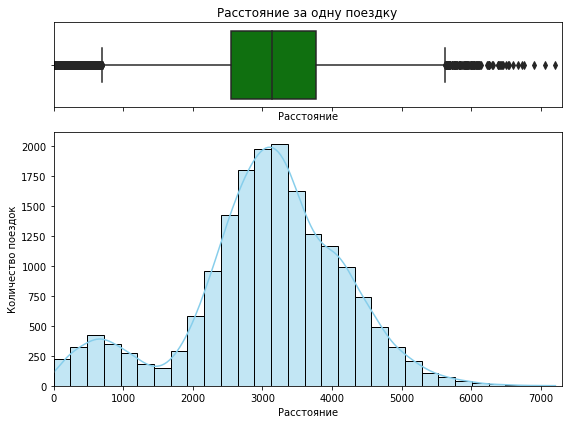

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Boxplot
sns.boxplot(x=data_rides['distance'], color='green', ax=ax1)
ax1.set_title('Расстояние за одну поездку')
ax1.set_xlabel('Расстояние')
ax1.set_xlim(0, 7300)
ax1.set(ylabel='') # Убираем подпись по y оси

# Гистограмма
sns.histplot(data_rides['distance'], color='skyblue', ax=ax2, kde=True, bins=30) # kde=True добавит кривую плотности
ax2.set_xlabel('Расстояние')
ax2.set_ylabel('Количество поездок')
ax2.set_xlim(0, 7300)

plt.tight_layout() # Чтобы графики не налезали друг на друга
plt.show()

### Продолжительность поездок

In [ ]:
data_rides['duration'].sort_values(ascending=False)

4215    40.82
4709    39.87
2623    39.53
1998    38.35
6453    38.27
         ... 
6768     0.50
7883     0.50
16179    0.50
9497     0.50
16704    0.50
Name: duration, Length: 18068, dtype: float64

In [ ]:
data_rides['duration'].describe()

count   18,068.00
mean        17.81
std          6.09
min          0.50
25%         13.60
50%         17.68
75%         21.72
max         40.82
Name: duration, dtype: float64

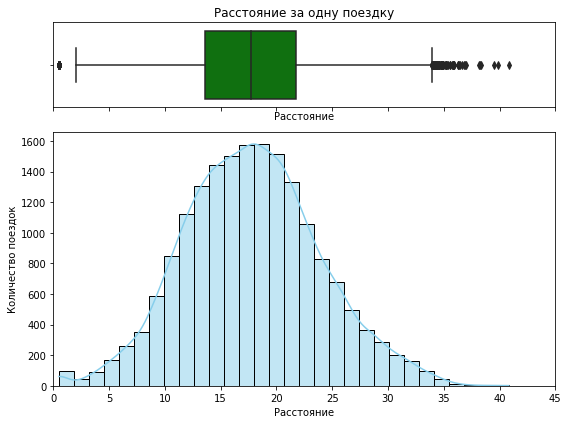

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Boxplot
sns.boxplot(x=data_rides['duration'], color='green', ax=ax1)
ax1.set_title('Расстояние за одну поездку')
ax1.set_xlabel('Расстояние')
ax1.set_xlim(0, 45)
ax1.set(ylabel='') # Убираем подпись по y оси

# Гистограмма
sns.histplot(data_rides['duration'], color='skyblue', ax=ax2, kde=True, bins=30) # kde=True добавит кривую плотности
ax2.set_xlabel('Расстояние')
ax2.set_ylabel('Количество поездок')
ax2.set_xlim(0, 45)

plt.tight_layout() # Чтобы графики не налезали друг на друга
plt.show()

<div style="border:solid lightblue 4px; padding: 20px">

    Вывод:

1) В общей статистике, самым частым встречающимся городом является Пятигорск, а Москва самый редкий город
2) При делении на категории тарифа Пятигорск также является самым частым городом.
3) Стоит отметить то, что в Краснодаре большой процент пользователей с бесплатным тарифом, а в платном тарифе пользователи из Краснодара встречаются реже всего. Но из-за большого числа пользователей бесплатного тарифа в общем показателе Краснодар занимает 4ое место.
4) По соотношению долей тарифов пользователей, лидирует бесплатный тариф 54.4%, соответственно пользователи с тарифом ультра 45.6%.
5) Пользователи с тарифом ультра занимают почти половину от общего количества, что может говорить о хорошей конверсии проекта.
6) Возраст клиентов находится в диапазоне от 12 до 43 лет, средний возраст составляет ~24,5 лет, медианный возраст клиета составляет 25 лет.
7) Среди пользователей некоторым менее 18 лет, именно с этого возраста разрешен прокат самокатов. В некоторых компаниях и регионах разрешено с 14 лет, но при письменном согласии родителей. В датасете минимальный возраст 12 лет, это явное нарушение существующих норм.
7) Самое большое расстояние, которое преодолел клиент - 7,211.01 метров, минимальное 0.86 м. А в средним клиент преодолевает 3,070 метров.
8) Максимальная продолжительность поездки составляет более 40 минут, минимальная- половина минуты. Средняя продолжительность поездки составляет почти 18 минут.
9) Так же важно отметить, что писутствуют поездки менне 1 минут, что является аномалией, возможно такие поезки пользователь совершал случайно, при это оплата списывалась.

## Шаг 3. Объединение данных

### Объединение данные о пользователях, поездках и подписках в один датафрейм.

In [ ]:
# объеденим первые 2 таблица по ключу айди пользователя
data= data_users.merge(data_rides, on='user_id')

In [ ]:
# объеденим полученную таблицу с таблице тарифов по его типу
data=data.merge(data_subscriptions, on='subscription_type')

In [ ]:
data.head()

   user_id  name  age    city subscription_type  distance  duration  \
0        1  Кира   22  Тюмень             ultra  4,409.92     25.60   
1        1  Кира   22  Тюмень             ultra  2,617.59     15.82   
2        1  Кира   22  Тюмень             ultra    754.16      6.23   
3        1  Кира   22  Тюмень             ultra  2,694.78     18.51   
4        1  Кира   22  Тюмень             ultra  4,028.69     26.27   

        date  month  minute_price  start_ride_price  subscription_fee  
0 2021-01-01      1             6                 0               199  
1 2021-01-18      1             6                 0               199  
2 2021-04-20      4             6                 0               199  
3 2021-08-11      8             6                 0               199  
4 2021-08-28      8             6                 0               199  

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   distance           18068 non-null  float64       
 6   duration           18068 non-null  float64       
 7   date               18068 non-null  datetime64[ns]
 8   month              18068 non-null  int64         
 9   minute_price       18068 non-null  int64         
 10  start_ride_price   18068 non-null  int64         
 11  subscription_fee   18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


### Создание ещё двух датафреймов: c данными о пользователях без подписки и с данными о пользователях с подпиской

In [ ]:
# бесплатный тариф
free_data = data.query("`subscription_type` == 'free'")
free_data.head()

      user_id   name  age  city subscription_type  distance  duration  \
6500      700  Айдар   22  Омск              free  2,515.69     14.94   
6501      700  Айдар   22  Омск              free    846.93     16.23   
6502      700  Айдар   22  Омск              free  4,004.43     20.02   
6503      700  Айдар   22  Омск              free  1,205.91      9.78   
6504      700  Айдар   22  Омск              free  3,047.38     17.43   

           date  month  minute_price  start_ride_price  subscription_fee  
6500 2021-01-02      1             8                50                 0  
6501 2021-02-01      2             8                50                 0  
6502 2021-02-04      2             8                50                 0  
6503 2021-02-10      2             8                50                 0  
6504 2021-02-14      2             8                50                 0  

In [ ]:
# тариф ультра
ultra_data = data.query("`subscription_type` == 'ultra'")
ultra_data.head()

   user_id  name  age    city subscription_type  distance  duration  \
0        1  Кира   22  Тюмень             ultra  4,409.92     25.60   
1        1  Кира   22  Тюмень             ultra  2,617.59     15.82   
2        1  Кира   22  Тюмень             ultra    754.16      6.23   
3        1  Кира   22  Тюмень             ultra  2,694.78     18.51   
4        1  Кира   22  Тюмень             ultra  4,028.69     26.27   

        date  month  minute_price  start_ride_price  subscription_fee  
0 2021-01-01      1             6                 0               199  
1 2021-01-18      1             6                 0               199  
2 2021-04-20      4             6                 0               199  
3 2021-08-11      8             6                 0               199  
4 2021-08-28      8             6                 0               199  

### Визуализируем информацию о расстоянии для пользователей обеих категорий

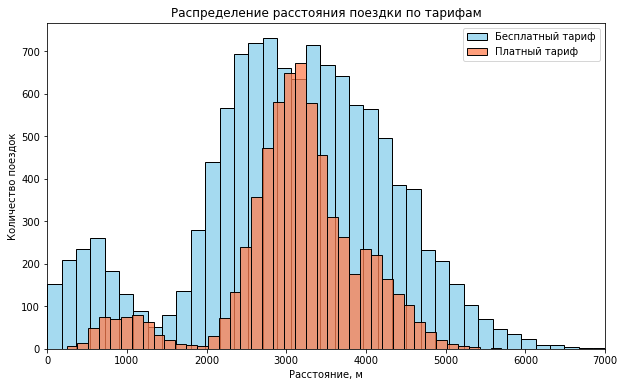

In [ ]:
plt.figure(figsize=(10, 6))

# гистограмма для бесплатного тарифа
sns.histplot(free_data['distance'], bins=40, kde=False, color='skyblue', label='Бесплатный тариф')
# гистограмма для тарифа ультра
sns.histplot(ultra_data['distance'], bins=40, kde=False, color='coral', label='Платный тариф')

# Настройка диапазона значений по оси x
plt.xlim(0, 7000) 
plt.title('Распределение расстояния поездки по тарифам')
plt.xlabel('Расстояние, м')
plt.ylabel('Количество поездок')
plt.legend(loc='upper right')
plt.show()

In [ ]:
free_data['distance'].describe()

count   11,568.00
mean     3,045.50
std      1,246.17
min          0.86
25%      2,366.56
50%      3,114.65
75%      3,905.70
max      7,211.01
Name: distance, dtype: float64

In [ ]:
ultra_data['distance'].describe()

count   6,500.00
mean    3,115.45
std       836.90
min       244.21
25%     2,785.44
50%     3,148.64
75%     3,560.57
max     5,699.77
Name: distance, dtype: float64

### Визуализируем информацию о продолжительности для пользователей обеих категорий

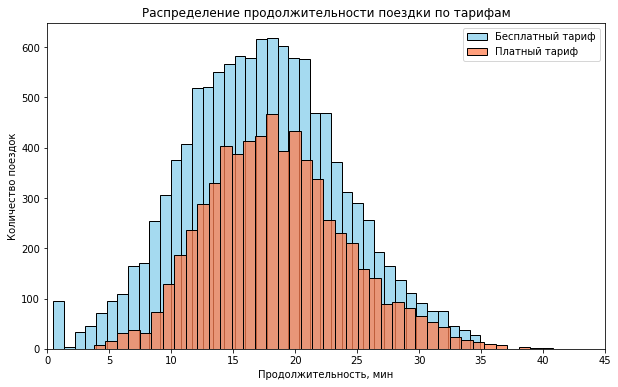

In [ ]:
plt.figure(figsize=(10, 6))

# гистограмма для бесплатного тарифа
sns.histplot(free_data['duration'], bins=40, kde=False, color='skyblue', label='Бесплатный тариф')
# гистограмма для тарифа ультра
sns.histplot(ultra_data['duration'], bins=40, kde=False, color='coral', label='Платный тариф')

# Настройка диапазона значений по оси x
plt.xlim(0, 45) 
plt.title('Распределение продолжительности поездки по тарифам')
plt.xlabel('Продолжительность, мин')
plt.ylabel('Количество поездок')
plt.legend(loc='upper right')
plt.show()

In [ ]:
free_data['duration'].describe()

count   11,568.00
mean        17.39
std          6.33
min          0.50
25%         12.96
50%         17.33
75%         21.59
max         34.95
Name: duration, dtype: float64

In [ ]:
ultra_data['duration'].describe()

count   6,500.00
mean       18.54
std         5.57
min         3.76
25%        14.52
50%        18.18
75%        21.88
max        40.82
Name: duration, dtype: float64

<div style="border:solid lightblue 4px; padding: 20px">

    Вывод:

1) Объединили 3 дата фрейма в 1
2) Разделили датафрейм на датафреймы с признаками "ультра" и "бесплатный"
3) Среднее время поездки бесплатного тарифа 17 минут, а растояние чуть больеш 3-х км
4) Для тарифа "ультра" среднее время поездки, а расстояние 2.7 до 3.5

## Шаг 4. Подсчёт выручки

In [ ]:
data['duration'] = np.ceil(data['duration']) 
data

       user_id     name  age       city subscription_type  distance  duration  \
0            1     Кира   22     Тюмень             ultra  4,409.92     26.00   
1            1     Кира   22     Тюмень             ultra  2,617.59     16.00   
2            1     Кира   22     Тюмень             ultra    754.16      7.00   
3            1     Кира   22     Тюмень             ultra  2,694.78     19.00   
4            1     Кира   22     Тюмень             ultra  4,028.69     27.00   
...        ...      ...  ...        ...               ...       ...       ...   
18063     1534  Альберт   25  Краснодар              free  3,781.10     20.00   
18064     1534  Альберт   25  Краснодар              free  2,840.42     22.00   
18065     1534  Альберт   25  Краснодар              free  3,826.19     19.00   
18066     1534  Альберт   25  Краснодар              free  2,902.31     17.00   
18067     1534  Альберт   25  Краснодар              free  2,371.71     16.00   

            date  month  mi

In [ ]:
# создадим сводную таблицу с необходимыми столбцами и с аггрегированными данными
agg_data = pd.pivot_table(
    data,
    index=['user_id', 'month', 'subscription_type'],
    values=['distance', 'duration', 'minute_price', 'start_ride_price', 'subscription_fee'],
    aggfunc={
        'distance': 'sum',
        'duration': 'sum',
        'minute_price': 'first', 
        'start_ride_price': 'first', 
        'subscription_fee': 'first'
    }
).reset_index()

#добавляем кол-во поездок
agg_data['trips'] = data.groupby(['user_id', 'month'])['user_id'].count().values
agg_data

       user_id  month subscription_type  distance  duration  minute_price  \
0            1      1             ultra  7,027.51     42.00             6   
1            1      4             ultra    754.16      7.00             6   
2            1      8             ultra  6,723.47     46.00             6   
3            1     10             ultra  5,809.91     32.00             6   
4            1     11             ultra  7,003.50     56.00             6   
...        ...    ...               ...       ...       ...           ...   
11326     1534      6              free  3,409.47     26.00             8   
11327     1534      8              free  7,622.45     48.00             8   
11328     1534      9              free  4,928.17     23.00             8   
11329     1534     11              free 13,350.02     78.00             8   
11330     1534     12              free  2,371.71     16.00             8   

       start_ride_price  subscription_fee  trips  
0                     0 

In [ ]:
#Для расчета помесячной выручки напишем собственную функцию
def revenue(row):
    start_sum = row['start_ride_price'] * row['trips']
    trip_sum = row['minute_price'] * row['duration']
    subscription_fee = row['subscription_fee']
    result = start_sum + trip_sum + subscription_fee
    return result

In [ ]:
agg_data['revenue'] = agg_data.apply(revenue, axis=1)
agg_data

       user_id  month subscription_type  distance  duration  minute_price  \
0            1      1             ultra  7,027.51     42.00             6   
1            1      4             ultra    754.16      7.00             6   
2            1      8             ultra  6,723.47     46.00             6   
3            1     10             ultra  5,809.91     32.00             6   
4            1     11             ultra  7,003.50     56.00             6   
...        ...    ...               ...       ...       ...           ...   
11326     1534      6              free  3,409.47     26.00             8   
11327     1534      8              free  7,622.45     48.00             8   
11328     1534      9              free  4,928.17     23.00             8   
11329     1534     11              free 13,350.02     78.00             8   
11330     1534     12              free  2,371.71     16.00             8   

       start_ride_price  subscription_fee  trips  revenue  
0              

In [ ]:
# проверим расчет формулы
check_data = agg_data.query('user_id == 1')
check_data

   user_id  month subscription_type  distance  duration  minute_price  \
0        1      1             ultra  7,027.51     42.00             6   
1        1      4             ultra    754.16      7.00             6   
2        1      8             ultra  6,723.47     46.00             6   
3        1     10             ultra  5,809.91     32.00             6   
4        1     11             ultra  7,003.50     56.00             6   
5        1     12             ultra  6,751.63     28.00             6   

   start_ride_price  subscription_fee  trips  revenue  
0                 0               199      2   451.00  
1                 0               199      1   241.00  
2                 0               199      2   475.00  
3                 0               199      2   391.00  
4                 0               199      3   535.00  
5                 0               199      2   367.00  

In [ ]:
agg_data['revenue'].describe()

count   11,331.00
mean       342.30
std        153.88
min         58.00
25%        234.00
50%        319.00
75%        415.00
max      1,444.00
Name: revenue, dtype: float64

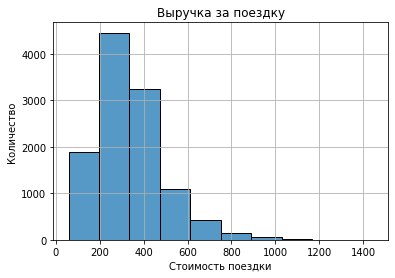

In [ ]:
sns.histplot(data=agg_data, x='revenue', bins=10)
plt.title('Выручка за поездку')
plt.xlabel('Стоимость поездки')
plt.ylabel('Количество')
plt.grid()
plt.show()

<div style="border:solid lightblue 4px; padding: 20px">

    Вывод:

1) Создали сводную таблицу с аггрегированными данными
2) Добавили столбец с количеством поездок
3) Создали функцию для расчета месячной выручки с каждого клиента
4) Исходя из данных мы узнали, что в среднем 1 поездка в среднем стоит 340 рублей, в большинстве случаев поездка стоила от 234 до 412 рублей, но бывали случаи, когда стоимость поездки составляла более 800 рублей.

## Шаг 4. Проверка гипотез

### Проверим гипотезу: тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. 

- H₀ (нулевая гипотеза): μ₁ ≤ μ₂ (среднее время поездки с подпиской не больше среднего времени поездки без подписки)
- H₁ (альтернативная гипотеза): μ₁ > μ₂ (среднее время поездки с подпиской больше среднего времени поездки без подписки)

In [ ]:

# Извлекаем столбцы с длительностью
ultra_duration = ultra_data['duration']
free_duration = free_data['duration']

# задаём уровень значимости
alpha = 0.05

# Проводим t-тест
results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


<div style="border:solid lightblue 4px; padding: 20px">

Вывод:
    
Полученное p-значение (1.28e-34) крайне мало и значительно меньше нашего заданного уровня значимости (0.05). Это значит, что вероятность получить наблюдаемое (или более экстремальное) различие в средней длительности поездок, если бы на самом деле средние длительности для обоих тарифов были бы одинаковыми или длительность “Ultra” была бы меньше, крайне мала.

### Проверим гипотезу: что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров

- H₀ (нулевая гипотеза): μ ≤ 3130 (среднее расстояние не превышает 3130 метров)
- H₁ (альтернативная гипотеза): μ > 3130 (среднее расстояние больше 3130 метров)

In [ ]:
# Извлекаем столбцы с длительностью
ultra_distance = ultra_data['distance']

# задаём уровень значимости
alpha = 0.05

# Проводим t-тест, для односторон
results = st.ttest_1samp(ultra_distance, 3130, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 0.9195368847849785
Нет оснований отвергнуть нулевую гипотезу


<div style="border:solid lightblue 4px; padding: 20px">

Вывод:

Полученное p-значение (0.9195) очень велико и значительно больше, чем наш установленный уровень значимости (0.05). Это означает, что вероятность получить наблюдаемое (или более экстремальное) значение среднего расстояния, если бы на самом деле среднее расстояние было равно 3130 метрам или меньше, довольно велика (около 92%).

### Проверим гипотезу: о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

- H₀ (Нулевая гипотеза): μ_ultra <= μ_free (Средняя помесячная выручка от пользователей с подпиской меньше или равна средней помесячной выручке от пользователей без подписки).

- H₁ (Альтернативная гипотеза): μ_ultra > μ_free (Средняя помесячная выручка от пользователей с подпиской больше средней помесячной выручки от пользователей без подписки).

In [ ]:
ultra_revenue = agg_data.loc[data.subscription_type == 'ultra', 'revenue'] 
free_revenue = agg_data.loc[data.subscription_type == 'free', 'revenue'] 

# задаём уровень значимости
alpha = 0.05

# Проводим t-тест
results = st.ttest_ind(ultra_revenue, free_revenue, alternative='greater')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 3.819490444237055e-17
Отвергаем нулевую гипотезу


<div style="border:solid lightblue 4px; padding: 20px">

Вывод:

“Отвергаем нулевую гипотезу. Статистический анализ показывает, что помесячная выручка от пользователей с подпиской значительно выше, чем от пользователей без подписки (p-value = 0.001). Различие между группами очень статистически значимо, что говорит о сильном положительном влиянии подписки на выручку."

### Каким тестом проверить гипотезу: если техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него?

<div style="border:solid lightblue 4px; padding: 20px">

Вывод:

В описанной ситуации, когда техническая команда обновила серверы, и мы хотим проверить, снизилось ли количество обращений в техподдержку, нам потребуется парный t-тест (paired t-test). Мы анализируем одну генеральную совокупность, в которой произошли изменения. В этом случае мы будем проверять, стало ли среднее количество обращений после обновления значимо меньше среднего количества обращений до обновления.

Гипотезы в таком случае будут сформулированы так:
- H0 (Нулевая гипотеза): μ1 <= μ2 (Среднее количество обращений до обновления меньше или равно среднему количеству обращений после обновления). Это означает, что обновление не снизило количество обращений или даже увеличило

- H1 (Альтернативная гипотеза): μ1 > μ2 (Среднее количество обращений до обновления больше среднего количества обращений после обновления). Это означает, что обновление снизило количество обращений.

В данном случае мы использовали бы левосторонний (или односторонний с проверкой снижения) тест: results = st.ttest_rel(before, after, alternative='greater')

## Шаг 6. Распределения


### Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж. 

Вероятность P(X <= 99): 0.4580


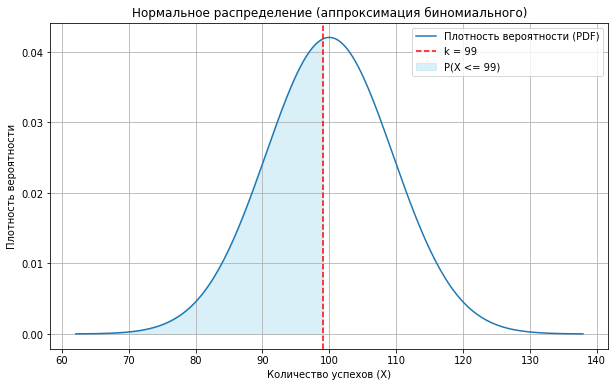

In [ ]:
n = 1000  # количество попыток
p = 0.1   # вероятность успеха
k = 99    # Пороговое значение

mu = n * p
sigma = (n * p * (1 - p))**0.5
distr = st.norm(mu, sigma)

result = distr.cdf(k)
print(f"Вероятность P(X <= {k}): {result:.4f}")

# 1. Создание массива значений x для графика
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200) # Диапазон x-ов, охватывающий большую часть распределения

# 2. Вычисление значений плотности вероятности (PDF) для каждого x
pdf_values = distr.pdf(x)

# 3. Вычисление значения интегральной функции распределения (CDF) для x = k
cdf_at_k = distr.cdf(k)

# 4. Построение графика
plt.figure(figsize=(10, 6))

# 4.1. График PDF
plt.plot(x, pdf_values, label='Плотность вероятности (PDF)')
# 4.2. Заливка области под кривой до k
x_fill = np.linspace(mu - 4*sigma, k, 200)
y_fill = distr.pdf(x_fill)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='skyblue', label=f'P(X <= {k})')
# 4.3. Вертикальная линия на k
plt.axvline(k, color='red', linestyle='--', label=f'k = {k}')
# 4.4. Подписи и заголовок
plt.xlabel('Количество успехов (X)')
plt.ylabel('Плотность вероятности')
plt.title('Нормальное распределение (аппроксимация биномиального)')
plt.legend()
plt.grid(True)
plt.show()

<div style="border:solid lightblue 4px; padding: 20px">
    Вывод:
    
1) Вероятность P(X <= 99) составляет примерно 45.58%. Это достаточно высокая вероятность.
2) Из этого можно сделать вывод, что есть значительная вероятность, что количество продлений подписки окажется ниже ожидаемого среднего (100).                                       

### Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

Вероятность P(X <= 399,500): 0.1537


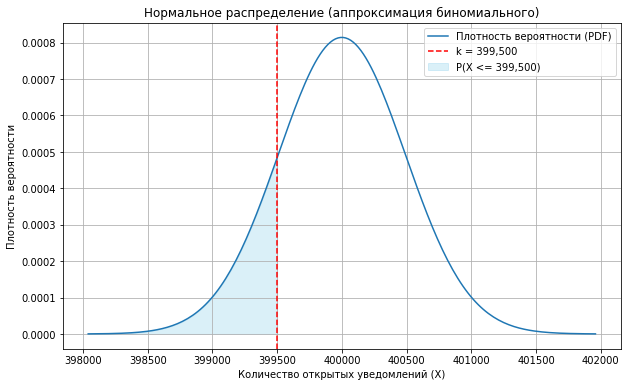

In [ ]:
n = 1000000  # количество уведомлений
p = 0.4       # вероятность открытия уведомления
k = 399500   # пороговое значение (не более)

mu = n * p
sigma = (n * p * (1 - p))**0.5
distr = st.norm(mu, sigma)

result = distr.cdf(k)
print(f"Вероятность P(X <= {k:,}): {result:.4f}")

# 1. Создание массива значений x для графика
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200) # Диапазон x-ов, охватывающий большую часть распределения

# 2. Вычисление значений плотности вероятности (PDF) для каждого x
pdf_values = distr.pdf(x)

# 3. Вычисление значения интегральной функции распределения (CDF) для x = k
cdf_at_k = distr.cdf(k)

# 4. Построение графика
plt.figure(figsize=(10, 6))

# 4.1. График PDF
plt.plot(x, pdf_values, label='Плотность вероятности (PDF)')
# 4.2. Заливка области под кривой до k
x_fill = np.linspace(mu - 4*sigma, k, 200)
y_fill = distr.pdf(x_fill)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='skyblue', label=f'P(X <= {k:,})')
# 4.3. Вертикальная линия на k
plt.axvline(k, color='red', linestyle='--', label=f'k = {k:,}')
# 4.4. Подписи и заголовок
plt.xlabel('Количество открытых уведомлений (X)')
plt.ylabel('Плотность вероятности')
plt.title('Нормальное распределение (аппроксимация биномиального)')
plt.legend()
plt.grid(True)
plt.show()

<div style="border:solid lightblue 4px; padding: 20px">
    Вывод:
    
1) Вероятность P(X <= 399,500) составляет примерно 15.4%.
2) Из этого можно сделать вывод, что количество открытых уведомлений будет не более 399,500 с вероятностью ~15%. Это важный результат для отдела маркетинга, позволяющий оценить, насколько вероятно отклонение от ожидаемого среднего числа открытий.

## Общие выводы

**Основные этапы и результаты:**

**Подготовка данных:**
Загружены и предобработаны три основных датасета. Проведена очистка данных, удалены дубликаты. В одном из датасетов типы данных были приведены в соответствие с фактическими значениями (в частности, столбец с датой был преобразован в тип datetime). Пропуски в данных не выявлены.

**Исследовательский анализ данных:**
Выявлены особенности распределения пользователей по городам: Пятигорск является самым часто встречающимся, а Москва – самым редким. В Краснодаре преобладает бесплатный тариф. В целом, бесплатный тариф является более популярным (54.4%), но тариф “ультра” занимает значительную долю (45.6%), что указывает на успешную конверсию проекта.
Определены основные характеристики пользователей: средний возраст составляет около 24.5 лет, диапазон возрастов от 12 до 43 лет.
Проанализированы характеристики поездок: среднее расстояние поездки около 3 км, а средняя продолжительность около 18 минут.

**Анализ тарифов:**
Датафреймы разделены на группы по тарифам. Средние значения времени и расстояния поездок различаются между тарифами, при этом средние значения для бесплатного тарифа чуть выше по сравнению с тарифом “ультра”.

**Анализ выручки:**
Создана сводная таблица с агрегированными данными и функция для расчета выручки с каждого клиента. Установлено, что в среднем одна поездка стоит 340 рублей, в большинстве случаев стоимость поездки от 234 до 412 рублей, но бывали случаи, когда стоимость поездки превышала 800 рублей.

**Статистический анализ:**
Определено, что для проверки гипотезы о снижении количества обращений в техподдержку после обновления серверов, необходим парный t-тест. Сформулированы соответствующие гипотезы.
Рассчитана вероятность того, что количество продлений подписки будет ниже ожидаемого среднего (100). Вероятность составила 45.58%, что указывает на значительную возможность такого события.
Рассчитана вероятность того, что количество открытых уведомлений не превысит 399 500. Эта вероятность составила 15.4%. Это может быть полезно для оценки эффективности маркетинговых кампаний.

**Общие выводы:**

- Данные хорошо подготовлены и структурированы для дальнейшего анализа.
- Пользователи, использующие бесплатный тариф, преобладают, но тариф “ультра” также пользуется большой популярностью.
- Наблюдаются различия в поведении пользователей в зависимости от тарифа и города.
- Средняя стоимость поездки и продолжительность поездки имеют свои особенности, в зависимости от выбранного тарифа и расстояния.
- Статистические анализы дали важные результаты, которые могут помочь в принятии решений.